In [3]:
!pip install xgboost
from xgboost import XGBClassifier

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.8/150.0 MB 10.1 MB/s eta 0:00:15
   - -------------------------------------- 3.9/150.0 MB 10.2 MB/s eta 0:00:15
   - -------------------------------------- 6.0/150.0 MB 10.6 MB/s eta 0:00:14
   -- ------------------------------------- 8.4/150.0 MB 10.4 MB/s eta 0:00:14
   -- ------------------------------------- 10.2/150.0 MB 9.5 MB/s eta 0:00:15
   --- ------------------------------------ 12.3/150.0 MB 9.6 MB/s eta 0:00:15
   --- ------------------------------------ 14.7/150.0 MB 9.6 MB/s eta 0:00:15
   ---- ----------------------------------- 16.8/150.0 MB 9.5 MB/s eta 0:00:14
   ----- ---------------------------------- 18.9/150.0 MB 9.6 MB/s eta 0:00:14
   ----- ---------------------------------- 21.0/150.0 MB 9.7 MB/s eta 0:00:14
   ------ --------------------------------- 23.3/150.0 MB 9.8 MB/s eta 0:00:13
   ------ --------------------------------- 26.2/150.0 MB 9.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import os


In [7]:
#Function
def train_and_evaluate(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Feature scaling (important for SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    # Define and train the XGBoost model
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [8]:
#Evaluate clean data

df_original = pd.read_csv("cleaned_data/adult_combined_cleaned.csv")
df_numeric = df_original.select_dtypes(include='number')
acc_original = train_and_evaluate(df_numeric, target_col='income_binary')
print(f"Original Dataset Accuracy- XGBoost: {acc_original:.4f}")

c:\Users\maria\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:26:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Original Dataset Accuracy- XGBoost: 0.8654


In [13]:
#evaluate other datasets
results = []

for filename in os.listdir('./anonymized_datasets'):
    if filename.startswith('adult_k') and filename.endswith('.csv'):
        k_value = int(filename.split('_')[1][1:]) 
        df_k = pd.read_csv(os.path.join('./anonymized_datasets', filename))
        df_numeric_k = df_k.select_dtypes(include='number')
        acc_k = train_and_evaluate(df_numeric_k, target_col='income_binary')
        results.append((k_value, acc_k))

results.sort()
for k, acc in results:
    print(f"k={k} → Accuracy: {acc:.4f}")

c:\Users\maria\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

k=5 → Accuracy: 0.8336
k=10 → Accuracy: 0.8399
k=25 → Accuracy: 0.7911
k=50 → Accuracy: 0.7920
k=100 → Accuracy: 0.7603


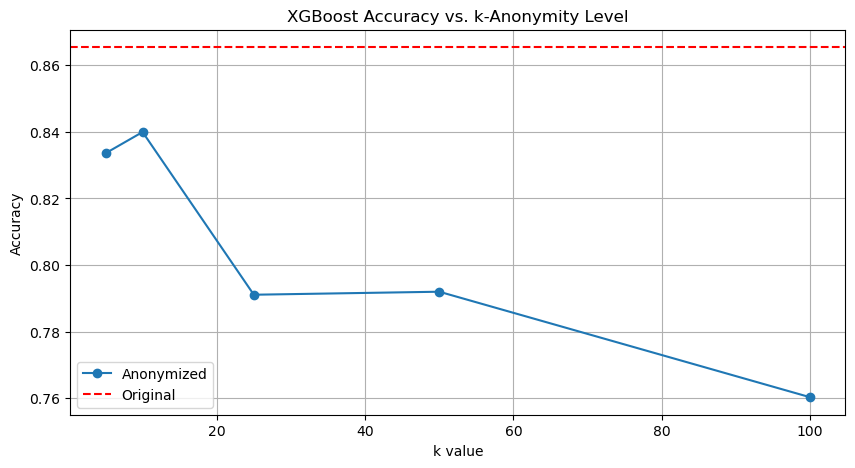

In [14]:
import matplotlib.pyplot as plt

ks = [k for k, _ in results]
accs = [acc for _, acc in results]

plt.figure(figsize=(10, 5))
plt.plot(ks, accs, marker='o', label='Anonymized')
plt.axhline(y=acc_original, color='r', linestyle='--', label='Original')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy vs. k-Anonymity Level")
plt.legend()
plt.grid(True)
plt.show()